# Anomaly Detection in Network Traffic Using Unsupervised Machine Learning
### A Comparative Study — Supervised vs Unsupervised Approaches



## 1. Library Imports and Configuration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'sans-serif'})

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading

In [6]:
bank_path   = '/Users/hasnainraza/Downloads/bank-full.csv'
credit_path = ('/Users/hasnainraza/Desktop/Organized Files/15 - Project Folders/Chapter 14 Techniques for Detecting Fraud Synthetic Credit Card Transaction Dataset/synthetic_card_transactions.csv')

bank_df   = pd.read_csv(bank_path)
credit_df = pd.read_csv(credit_path)

print(' Bank Dataset ')
print(f'Shape   : {bank_df.shape}')
print(f'Columns : {bank_df.columns.tolist()}')
print()
print(' Credit Card Dataset')
print(f'Shape   : {credit_df.shape}')
print(f'Columns : {credit_df.columns.tolist()}')

 Bank Dataset 
Shape   : (45211, 17)
Columns : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'class']

 Credit Card Dataset
Shape   : (10000, 2)
Columns : ['Transaction Index', 'Amount']


## 3. Exploratory Data Analysis — Bank Dataset

### 3.1 Dataset Overview

In [7]:
print('Data Types:')
print(bank_df.dtypes)
print()
print('Missing Values:')
print(bank_df.isnull().sum())
print()
bank_df.describe()

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
class        object
dtype: object

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
class        0
dtype: int64



,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### 3.2 Numerical Feature Distributions

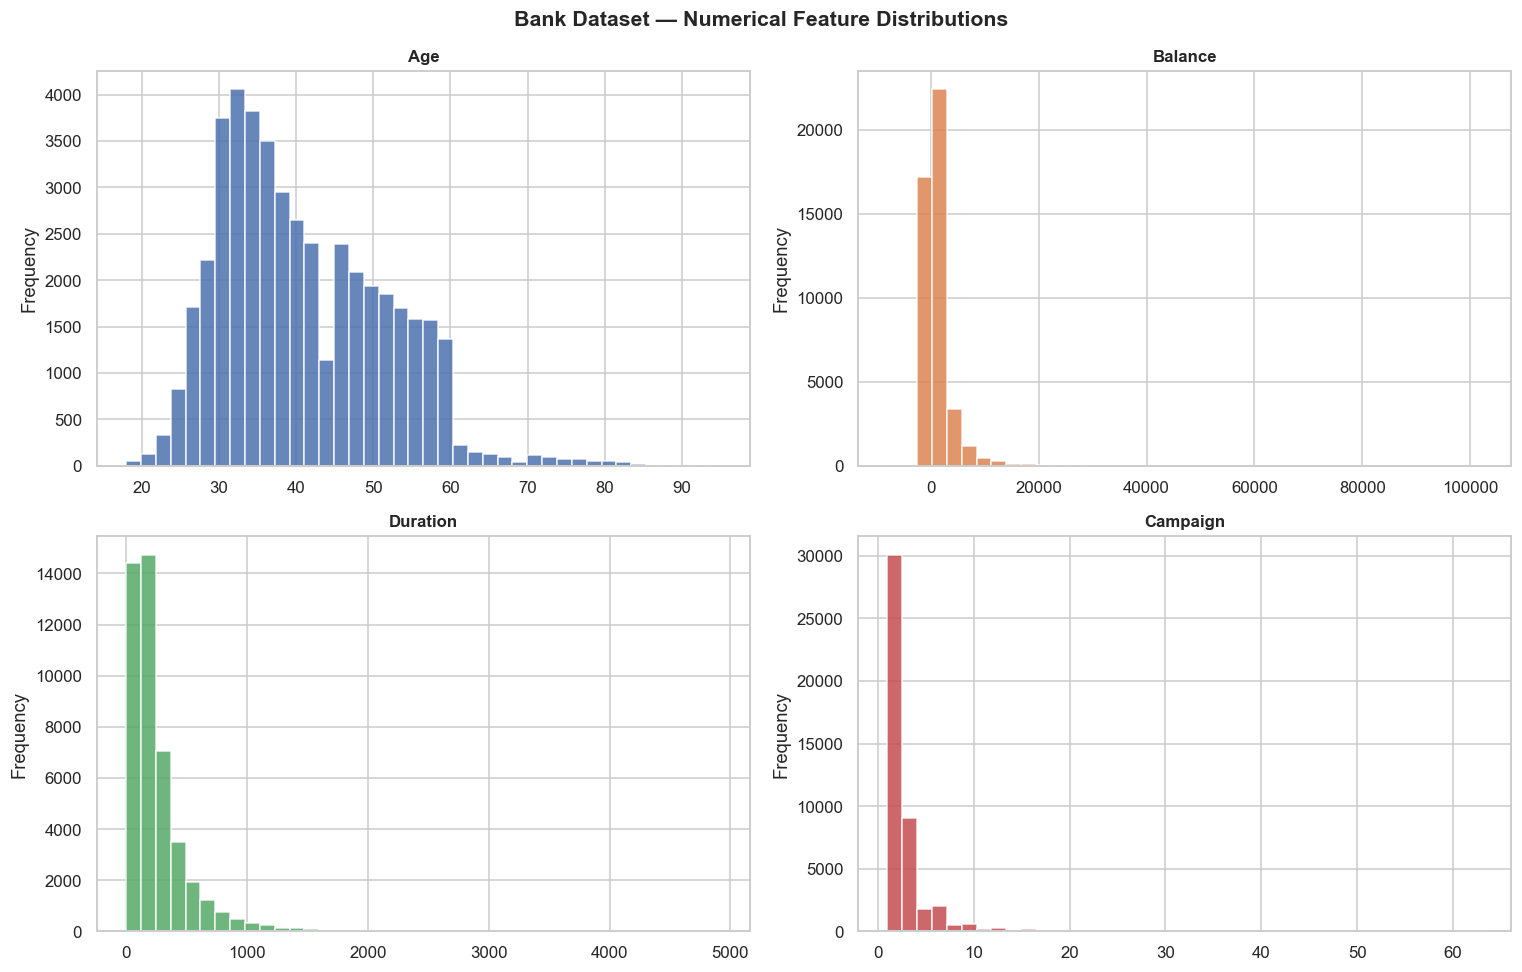

In [8]:
num_cols   = ['age', 'balance', 'duration', 'campaign']
bar_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Bank Dataset — Numerical Feature Distributions',
             fontsize=14, fontweight='bold')

for ax, col, c in zip(axes.flatten(), num_cols, bar_colors):
    ax.hist(bank_df[col], bins=40, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(col.capitalize(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('bank_distributions.png', bbox_inches='tight')
plt.show()

### 3.3 Target Class and Job Distribution

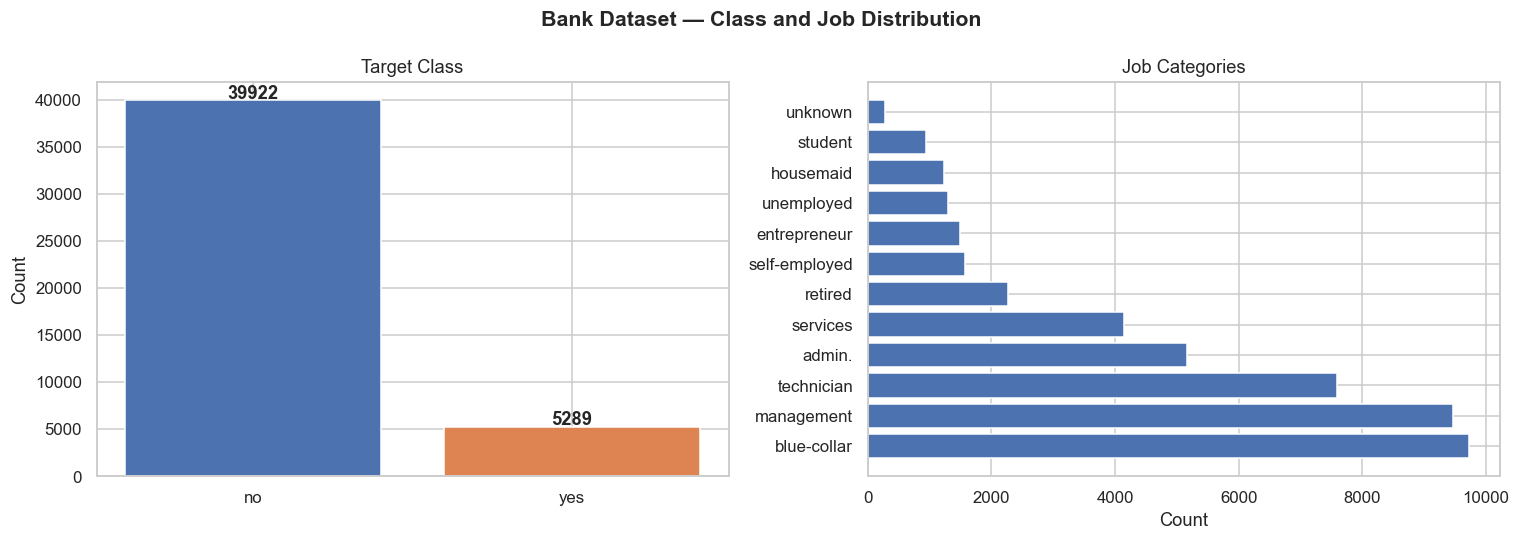

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bank Dataset — Class and Job Distribution',
             fontsize=14, fontweight='bold')

cc = bank_df['class'].value_counts()
axes[0].bar(cc.index, cc.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Target Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

jc = bank_df['job'].value_counts()
axes[1].barh(jc.index, jc.values, color='#4C72B0', edgecolor='white')
axes[1].set_title('Job Categories')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('bank_categorical.png', bbox_inches='tight')
plt.show()

### 3.4 Feature Correlation Heatmap

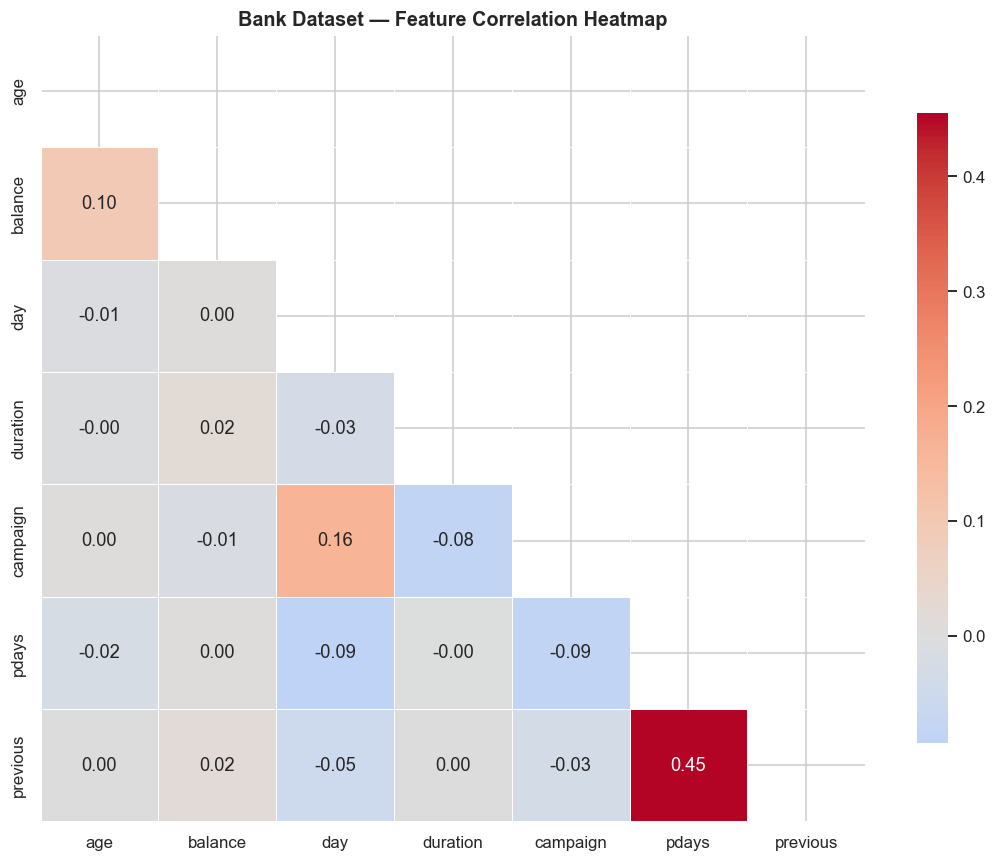

In [10]:
bank_num  = bank_df.select_dtypes(include='number')
corr_bank = bank_num.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_bank, dtype=bool))
sns.heatmap(corr_bank, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Bank Dataset — Feature Correlation Heatmap',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bank_correlation.png', bbox_inches='tight')
plt.show()

### 3.5 Feature Distribution by Class

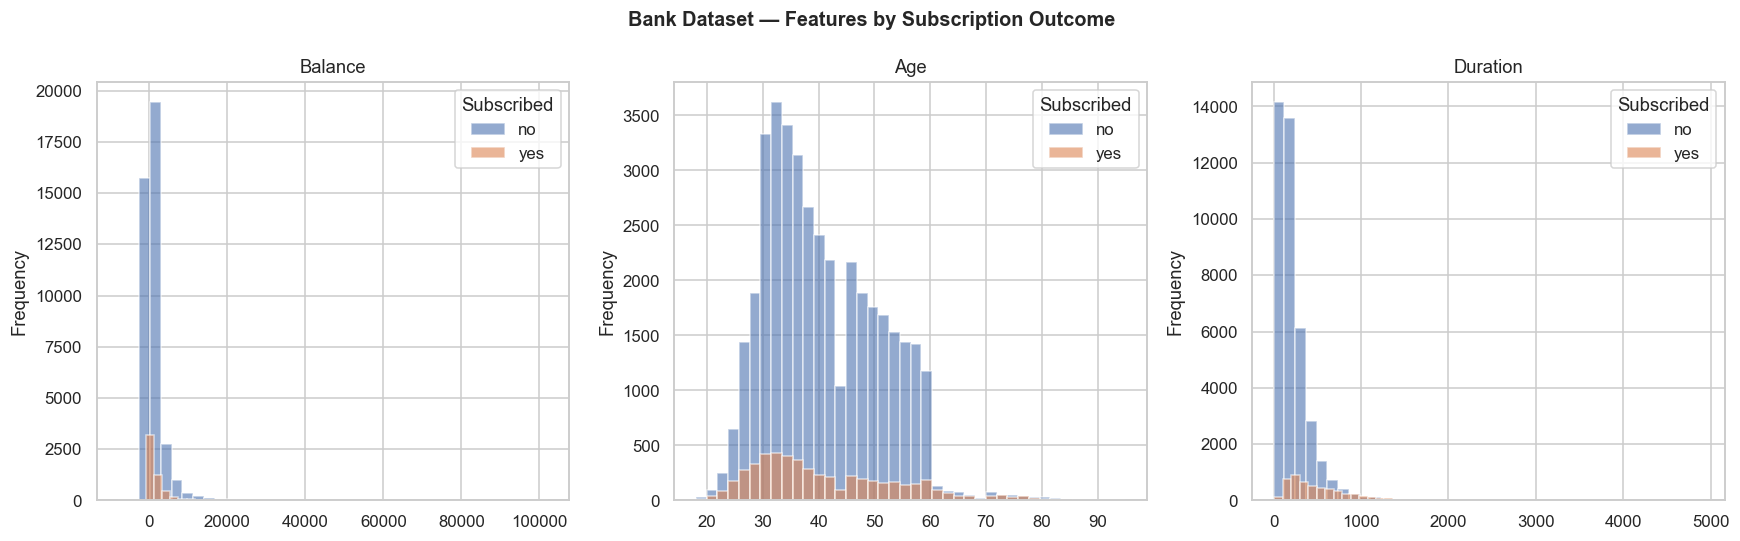

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bank Dataset — Features by Subscription Outcome',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['balance', 'age', 'duration']):
    for label, color in zip(['no', 'yes'], ['#4C72B0', '#DD8452']):
        ax.hist(bank_df[bank_df['class'] == label][col],
                bins=40, alpha=0.6, color=color,
                label=label, edgecolor='white')
    ax.set_title(col.capitalize())
    ax.set_ylabel('Frequency')
    ax.legend(title='Subscribed')

plt.tight_layout()
plt.savefig('bank_by_class.png', bbox_inches='tight')
plt.show()

## 4. Exploratory Data Analysis — Credit Card Dataset

### 4.1 Dataset Overview

In [12]:
print('Data Types:')
print(credit_df.dtypes)
print()
print('Missing Values:', credit_df.isnull().sum().sum())
print()
credit_df.describe()

Data Types:
Transaction Index      int64
Amount               float64
dtype: object

Missing Values: 0



,Transaction Index,Amount
count,10000.00000,10000.000000
mean,5000.50000,105.841893
std,2886.89568,97.166307
min,1.00000,0.000000
25%,2500.75000,66.592835
50%,5000.50000,100.155196
75%,7500.25000,134.098887
max,10000.00000,1945.662773


### 4.2 Transaction Amount Distribution

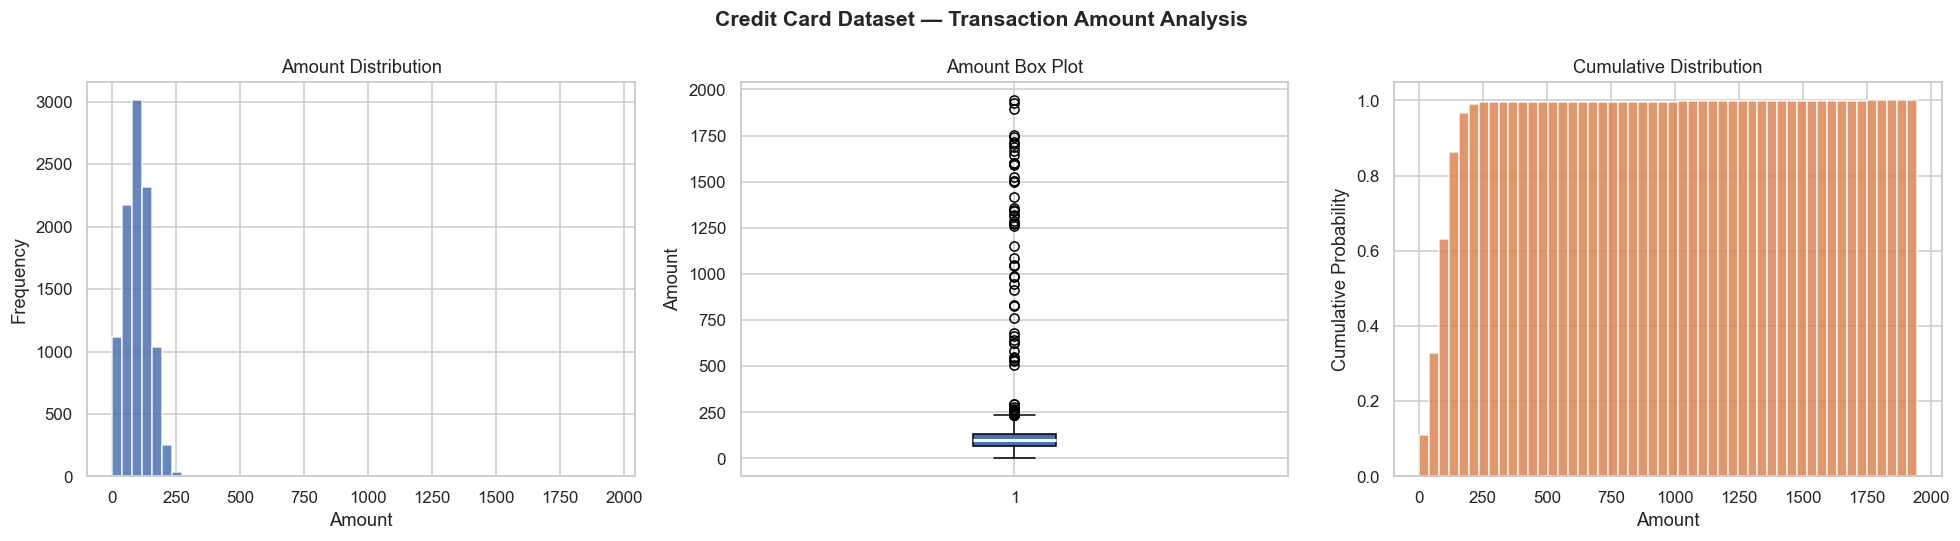

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Credit Card Dataset — Transaction Amount Analysis',
             fontsize=14, fontweight='bold')

axes[0].hist(credit_df['Amount'], bins=50, color='#4C72B0',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(credit_df['Amount'], vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', color='black'),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Amount Box Plot')
axes[1].set_ylabel('Amount')

axes[2].hist(credit_df['Amount'], bins=50, color='#DD8452',
             edgecolor='white', alpha=0.85, density=True, cumulative=True)
axes[2].set_title('Cumulative Distribution')
axes[2].set_xlabel('Amount')
axes[2].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.savefig('credit_amount_analysis.png', bbox_inches='tight')
plt.show()

### 4.3 Statistical Outlier Identification

In [14]:
Q1 = credit_df['Amount'].quantile(0.25)
Q3 = credit_df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = credit_df[(credit_df['Amount'] < lower) |
                         (credit_df['Amount'] > upper)]

print(f'Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}')
print(f'Lower Bound = {lower:.2f}, Upper Bound = {upper:.2f}')
print(f'IQR Outliers: {len(outliers_iqr)} / {len(credit_df)} '
      f'({len(outliers_iqr)/len(credit_df)*100:.2f}%)')

Q1 = 66.59, Q3 = 134.10, IQR = 67.51
Lower Bound = -34.67, Upper Bound = 235.36
IQR Outliers: 87 / 10000 (0.87%)


## 5. Data Preprocessing

### 5.1 Bank Dataset

In [15]:
bank_enc = bank_df.copy()
le = LabelEncoder()

for col in bank_enc.columns:
    if bank_enc[col].dtype == object:
        bank_enc[col] = le.fit_transform(bank_enc[col].astype(str))

X_bank = bank_enc.drop(columns=['class'])
y_bank = bank_enc['class']

scaler_bank   = StandardScaler()
X_bank_scaled = scaler_bank.fit_transform(X_bank)

print(f'Feature matrix : {X_bank_scaled.shape}')
print(f'Target (0=no, 1=yes):')
print(y_bank.value_counts())

Feature matrix : (45211, 16)
Target (0=no, 1=yes):
class
0    39922
1     5289
Name: count, dtype: int64


### 5.2 Credit Card Dataset

In [16]:
X_credit = credit_df[['Amount']].copy()

scaler_credit   = StandardScaler()
X_credit_scaled = scaler_credit.fit_transform(X_credit)

print(f'Feature matrix : {X_credit_scaled.shape}')
print('(Single feature — Amount; no target labels available)')

Feature matrix : (10000, 1)
(Single feature — Amount; no target labels available)


## 6. Dimensionality Reduction — PCA (Bank Dataset)

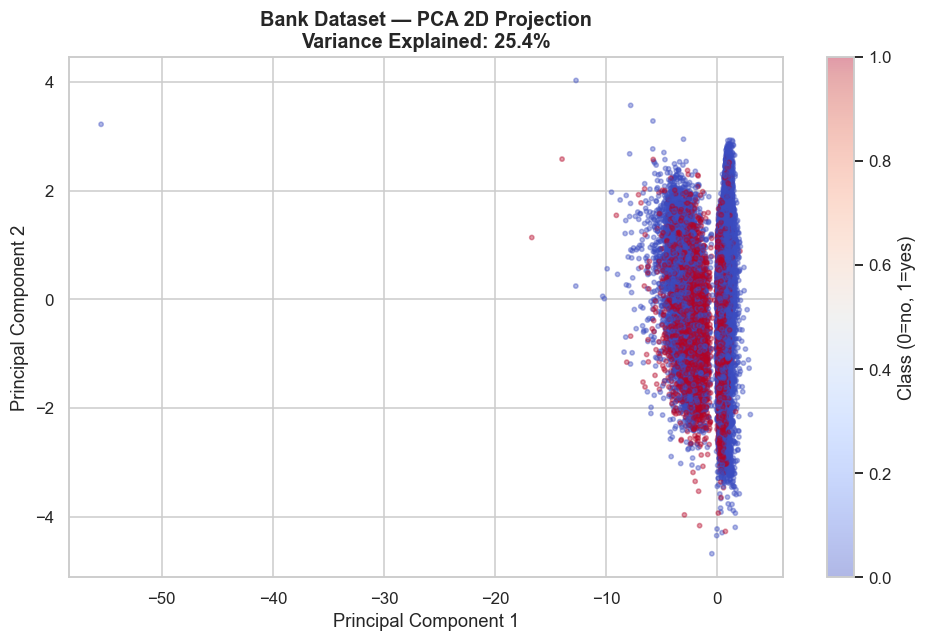

Note: PCA not applied to Credit Card dataset (only 1 feature).


In [17]:
pca_bank     = PCA(n_components=2, random_state=42)
X_bank_pca   = pca_bank.fit_transform(X_bank_scaled)
var_explained = sum(pca_bank.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_bank_pca[:,0], X_bank_pca[:,1],
                c=y_bank, cmap='coolwarm', alpha=0.4, s=8)
ax.set_title(f'Bank Dataset — PCA 2D Projection\n'
             f'Variance Explained: {var_explained:.1f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.colorbar(sc, ax=ax, label='Class (0=no, 1=yes)')
plt.tight_layout()
plt.savefig('pca_bank.png', bbox_inches='tight')
plt.show()

print('Note: PCA not applied to Credit Card dataset (only 1 feature).')

## 7. Unsupervised Model — Isolation Forest

Isolation Forest is applied to both datasets for anomaly detection.

In [18]:
iso_bank = IsolationForest(n_estimators=100, contamination=0.1,
                           random_state=42)
iso_bank.fit(X_bank_scaled)
bank_iso_pred   = np.where(iso_bank.predict(X_bank_scaled) == -1, 1, 0)
bank_iso_scores = iso_bank.decision_function(X_bank_scaled) * -1

iso_credit = IsolationForest(n_estimators=100, contamination=0.05,
                             random_state=42)
iso_credit.fit(X_credit_scaled)
credit_iso_pred   = np.where(iso_credit.predict(X_credit_scaled) == -1, 1, 0)
credit_iso_scores = iso_credit.decision_function(X_credit_scaled) * -1

print(' Isolation Forest Results ')
print(f'Bank   — Anomalies: {bank_iso_pred.sum():,} / '
      f'{len(bank_iso_pred):,} '
      f'({bank_iso_pred.mean()*100:.1f}%)')
print(f'Credit — Anomalies: {credit_iso_pred.sum():,} / '
      f'{len(credit_iso_pred):,} '
      f'({credit_iso_pred.mean()*100:.1f}%)')

 Isolation Forest Results 
Bank   — Anomalies: 4,521 / 45,211 (10.0%)
Credit — Anomalies: 500 / 10,000 (5.0%)


### 7.1 Bank Dataset — Isolation Forest Visualisation (PCA Space)

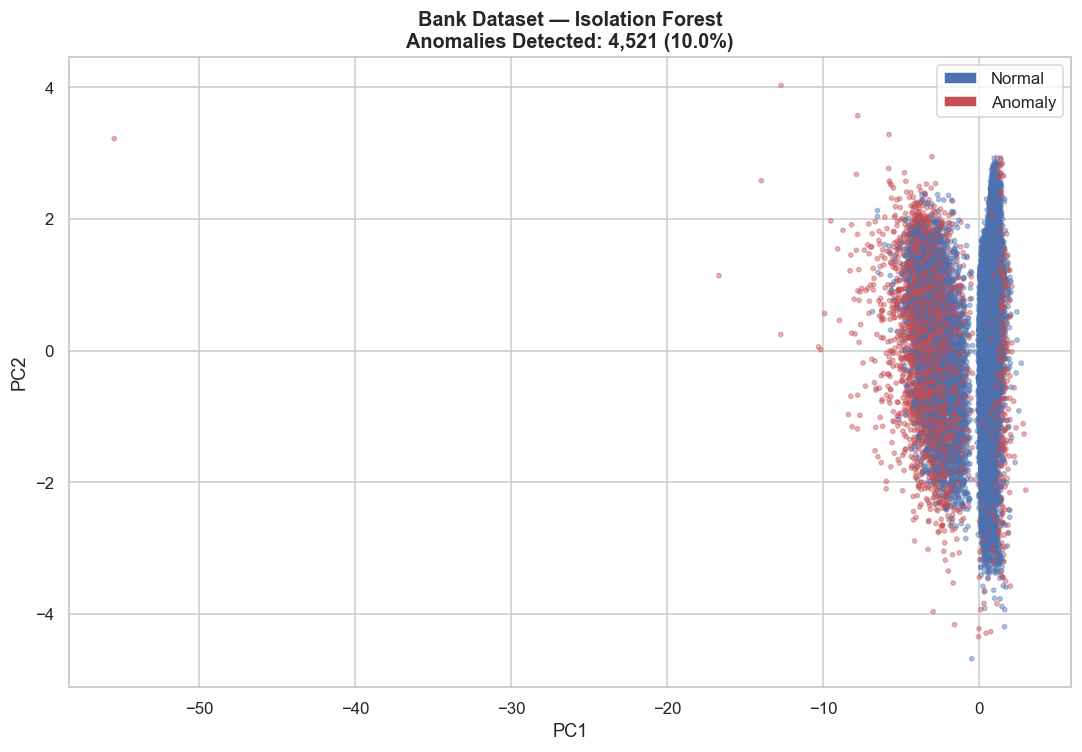

In [19]:
legend_el = [Patch(facecolor='#4C72B0', label='Normal'),
             Patch(facecolor='#C44E52', label='Anomaly')]

colors_b = ['#4C72B0' if x == 0 else '#C44E52' for x in bank_iso_pred]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_bank_pca[:,0], X_bank_pca[:,1], c=colors_b, alpha=0.4, s=8)
ax.set_title(f'Bank Dataset — Isolation Forest\n'
             f'Anomalies Detected: {bank_iso_pred.sum():,} '
             f'({bank_iso_pred.mean()*100:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(handles=legend_el)
plt.tight_layout()
plt.savefig('iso_forest_bank.png', bbox_inches='tight')
plt.show()

### 7.2 Credit Card Dataset — Isolation Forest Visualisation

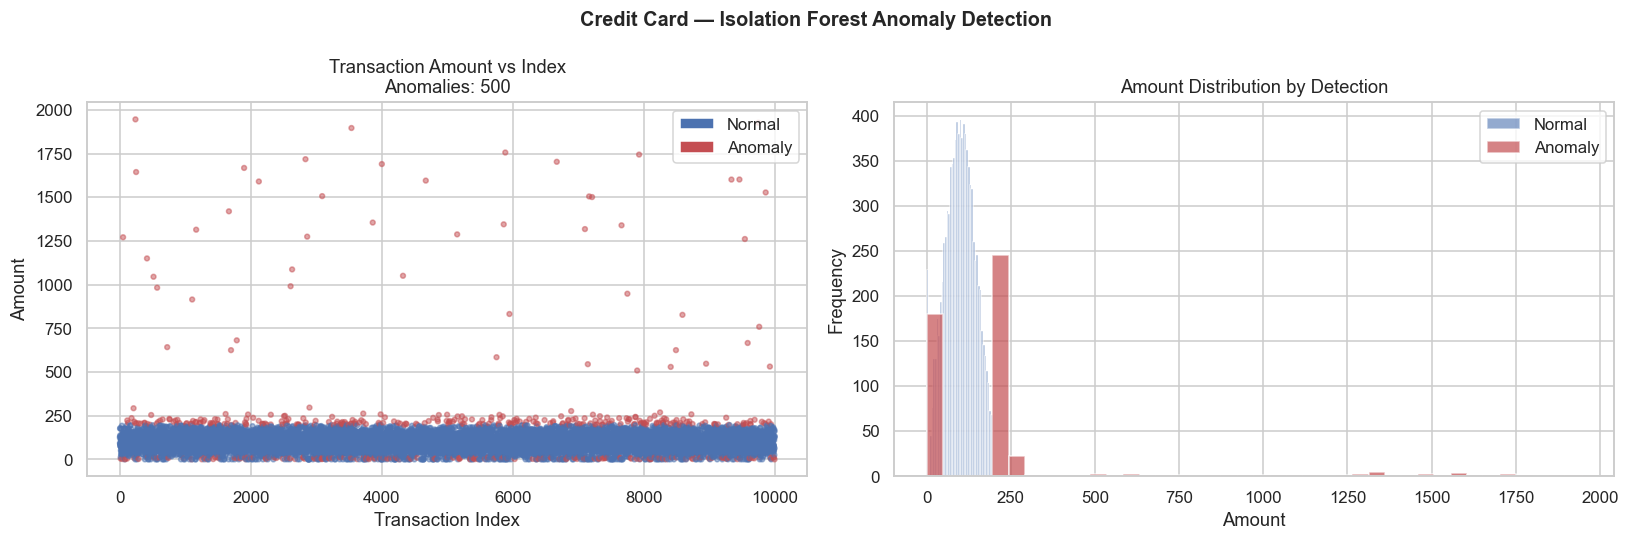

In [20]:
colors_c = ['#4C72B0' if x == 0 else '#C44E52' for x in credit_iso_pred]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Credit Card — Isolation Forest Anomaly Detection',
             fontsize=13, fontweight='bold')

axes[0].scatter(credit_df.index, credit_df['Amount'],
                c=colors_c, alpha=0.5, s=10)
axes[0].set_title(f'Transaction Amount vs Index\n'
                  f'Anomalies: {credit_iso_pred.sum()}')
axes[0].set_xlabel('Transaction Index')
axes[0].set_ylabel('Amount')
axes[0].legend(handles=legend_el)

axes[1].hist(credit_df.loc[credit_iso_pred == 0, 'Amount'],
             bins=40, alpha=0.6, color='#4C72B0',
             label='Normal', edgecolor='white')
axes[1].hist(credit_df.loc[credit_iso_pred == 1, 'Amount'],
             bins=40, alpha=0.7, color='#C44E52',
             label='Anomaly', edgecolor='white')
axes[1].set_title('Amount Distribution by Detection')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('iso_forest_credit.png', bbox_inches='tight')
plt.show()

## 8. Supervised Model — Random Forest (Bank Dataset)



In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bank_scaled, y_bank, test_size=0.2,
    random_state=42, stratify=y_bank
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print()
print('Random Forest — Classification Report ')
print(classification_report(y_test, rf_pred))
print(f'ROC-AUC: {rf_auc:.4f}')

Training samples : 36168
Test samples     : 9043

Random Forest — Classification Report 
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.66      0.41      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043

ROC-AUC: 0.9242


### 8.1 Confusion Matrix

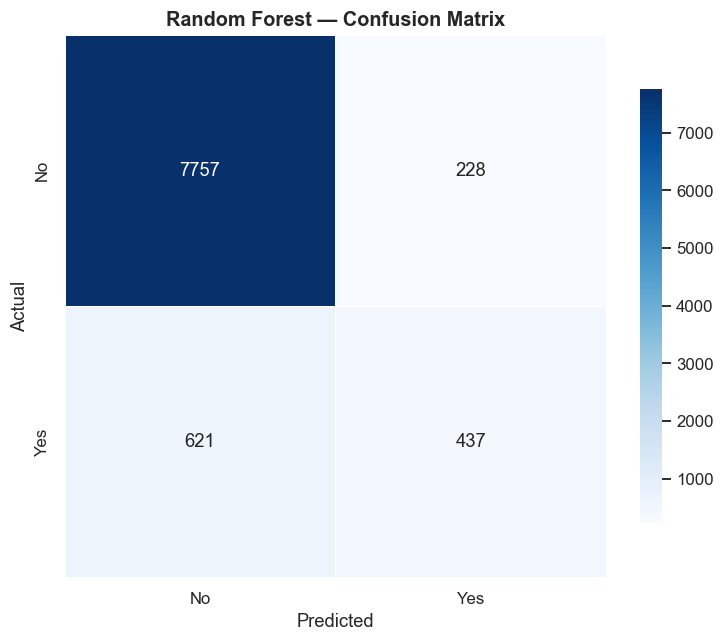

In [22]:
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Random Forest — Confusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', bbox_inches='tight')
plt.show()

### 8.2 ROC Curve

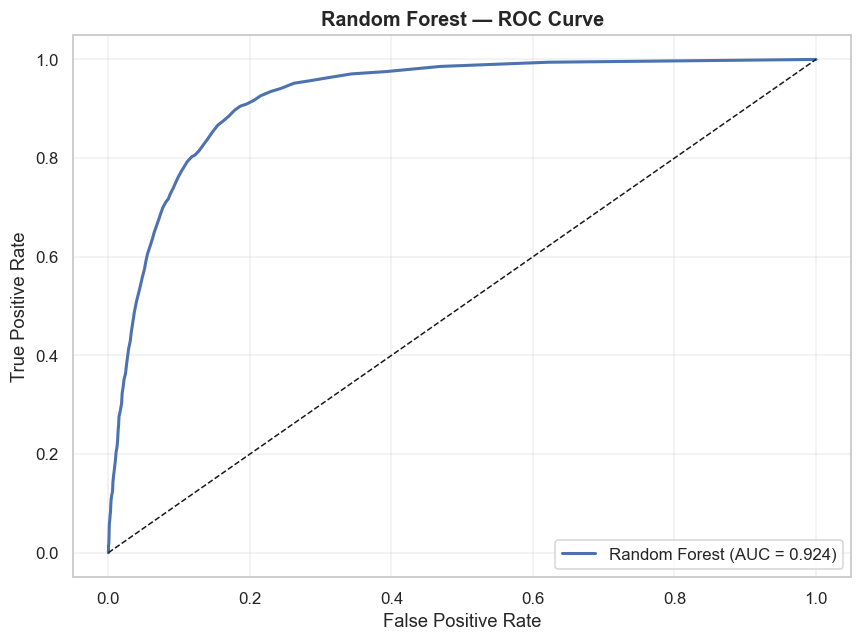

In [23]:
fpr, tpr, _ = roc_curve(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#4C72B0', lw=2,
        label=f'Random Forest (AUC = {rf_auc:.3f})')
ax.plot([0,1], [0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest — ROC Curve',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_rf.png', bbox_inches='tight')
plt.show()

### 8.3 Feature Importance

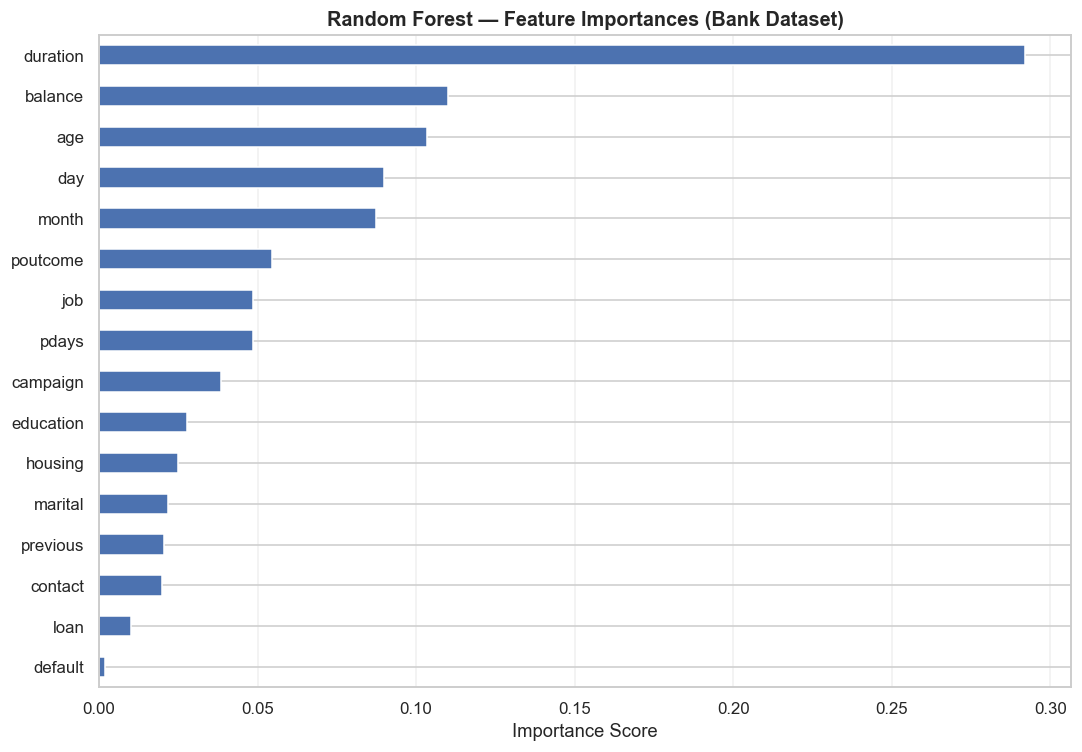

In [24]:
feat_imp = pd.Series(rf.feature_importances_,
                     index=X_bank.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', color='#4C72B0', edgecolor='white', ax=ax)
ax.invert_yaxis()
ax.set_title('Random Forest — Feature Importances (Bank Dataset)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## 9. Model Comparison Summary

In [25]:
iso_bank_auc = roc_auc_score(y_bank, bank_iso_scores)

summary = pd.DataFrame({
    'Model'   : ['Isolation Forest', 'Random Forest'],
    'Type'    : ['Unsupervised', 'Supervised'],
    'Dataset' : ['Bank', 'Bank'],
    'ROC-AUC' : [round(iso_bank_auc, 4), round(rf_auc, 4)],
    'Notes'   : [
        f'Anomalies detected: {bank_iso_pred.sum():,}',
        f'Accuracy via classification report'
    ]
})

print('Model Comparison ')
print(summary.to_string(index=False))

Model Comparison 
           Model         Type Dataset  ROC-AUC                              Notes
Isolation Forest Unsupervised    Bank   0.6785          Anomalies detected: 4,521
   Random Forest   Supervised    Bank   0.9242 Accuracy via classification report


### 9.1 AUC Comparison Bar Chart

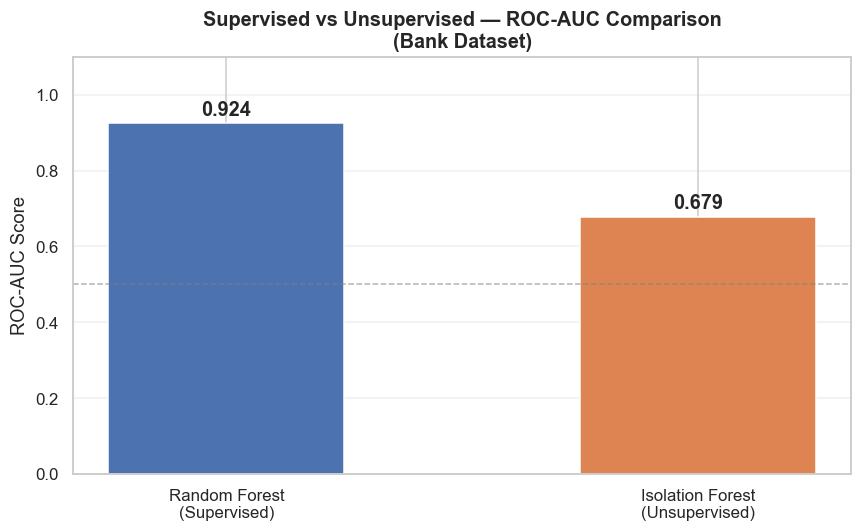

In [26]:
models = ['Random Forest\n(Supervised)', 'Isolation Forest\n(Unsupervised)']
aucs   = [rf_auc, iso_bank_auc]
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, aucs, color=colors, edgecolor='white', width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Supervised vs Unsupervised — ROC-AUC Comparison\n(Bank Dataset)',
             fontsize=13, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 10. Further Development — SMOTE Class Balancing



In [ ]:

from imblearn.over_sampling import SMOTE

print('Class distribution BEFORE SMOTE:')
print(pd.Series(y_train).value_counts())
print(f'Imbalance ratio: {pd.Series(y_train).value_counts()[0] / pd.Series(y_train).value_counts()[1]:.2f}:1')


Class distribution BEFORE SMOTE:
class
0    31937
1     4231
Name: count, dtype: int64
Imbalance ratio: 7.55:1


In [34]:

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('Class distribution AFTER SMOTE:')
print(pd.Series(y_train_sm).value_counts())
print(f'New training size: {X_train_sm.shape[0]:,} samples')


Class distribution AFTER SMOTE:
class
0    31937
1    31937
Name: count, dtype: int64
New training size: 63,874 samples


### 10.1 Train Random Forest on SMOTE-Balanced Data

In [35]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)

rf_smote_pred  = rf_smote.predict(X_test)
rf_smote_proba = rf_smote.predict_proba(X_test)[:, 1]
rf_smote_auc   = roc_auc_score(y_test, rf_smote_proba)

print('Random Forest + SMOTE — Classification Report')
print(classification_report(y_test, rf_smote_pred))
print(f'ROC-AUC (SMOTE): {rf_smote_auc:.4f}')


Random Forest + SMOTE — Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7985
           1       0.56      0.62      0.59      1058

    accuracy                           0.90      9043
   macro avg       0.75      0.78      0.77      9043
weighted avg       0.90      0.90      0.90      9043

ROC-AUC (SMOTE): 0.9265


### 10.2 SMOTE Confusion Matrix

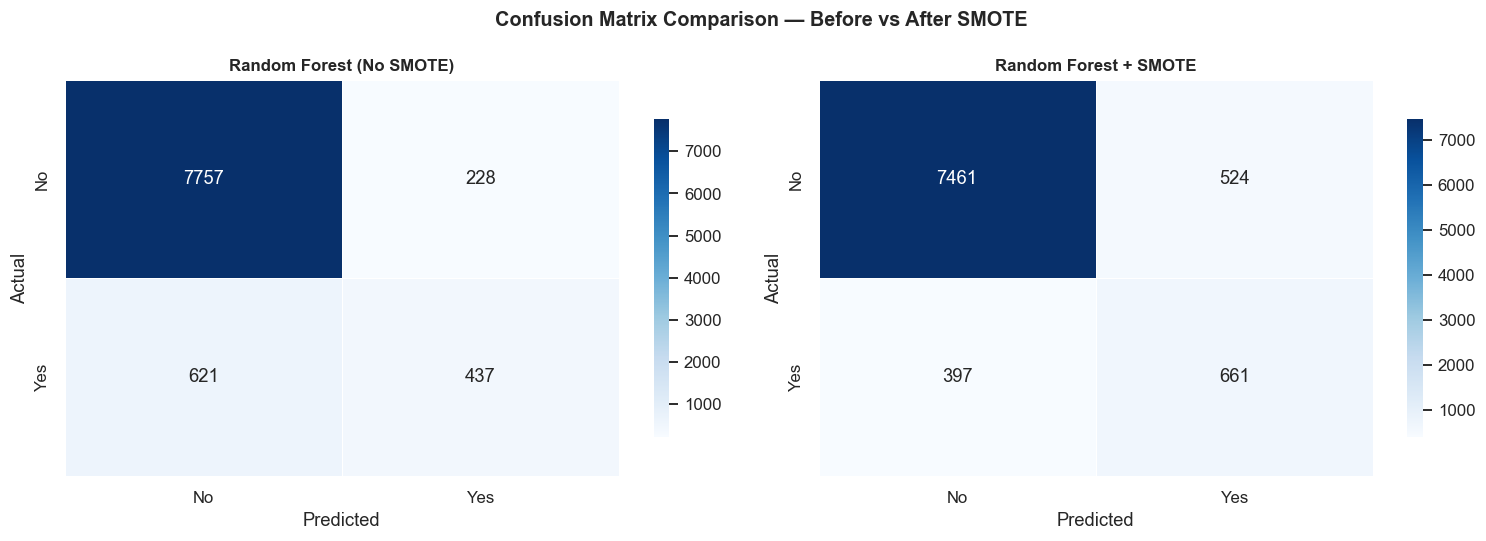

In [36]:
cm_smote = confusion_matrix(y_test, rf_smote_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix Comparison — Before vs After SMOTE',
             fontsize=13, fontweight='bold')

for ax, cm_data, title in zip(axes,
                               [cm, cm_smote],
                               ['Random Forest (No SMOTE)', 'Random Forest + SMOTE']):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'],
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_smote.png', bbox_inches='tight')
plt.show()


### 10.3 ROC Curve Comparison — Before vs After SMOTE

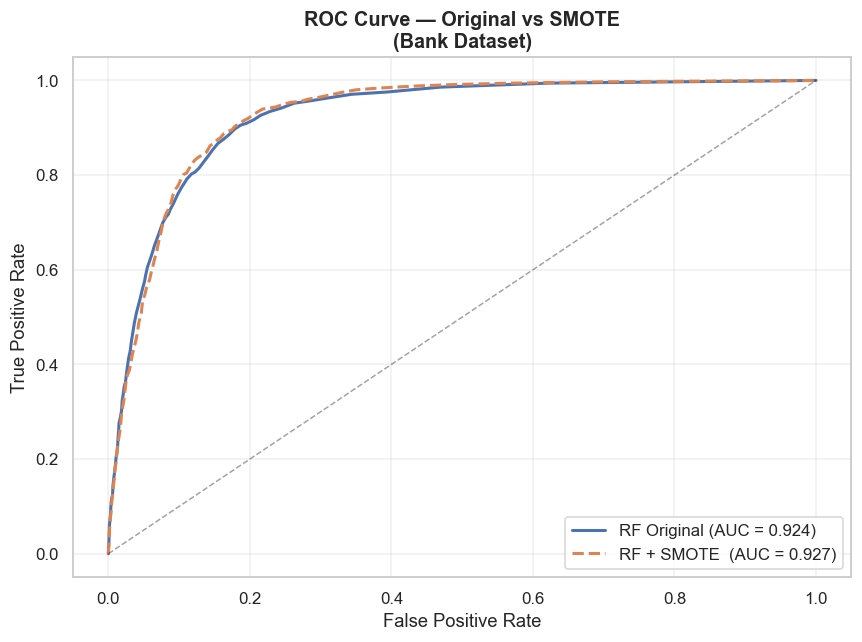

In [37]:
fpr_sm, tpr_sm, _ = roc_curve(y_test, rf_smote_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#4C72B0', lw=2,
        label=f'RF Original (AUC = {rf_auc:.3f})')
ax.plot(fpr_sm, tpr_sm, color='#DD8452', lw=2, linestyle='--',
        label=f'RF + SMOTE  (AUC = {rf_smote_auc:.3f})')
ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Original vs SMOTE\n(Bank Dataset)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_smote_comparison.png', bbox_inches='tight')
plt.show()


### 10.4 Recall & Precision Comparison — Before vs After SMOTE

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Metric'          : ['Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)', 'ROC-AUC'],
    'Original RF'     : [
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        rf_auc
    ],
    'RF + SMOTE'      : [
        precision_score(y_test, rf_smote_pred),
        recall_score(y_test, rf_smote_pred),
        f1_score(y_test, rf_smote_pred),
        rf_smote_auc
    ]
}

cmp_df = pd.DataFrame(metrics)
cmp_df[['Original RF', 'RF + SMOTE']] = cmp_df[['Original RF', 'RF + SMOTE']].round(4)
print('Performance Comparison — Original vs SMOTE')
print(cmp_df.to_string(index=False))


Performance Comparison — Original vs SMOTE
           Metric  Original RF  RF + SMOTE
Precision (Fraud)       0.6571      0.5578
   Recall (Fraud)       0.4130      0.6248
 F1-Score (Fraud)       0.5073      0.5894
          ROC-AUC       0.9242      0.9265


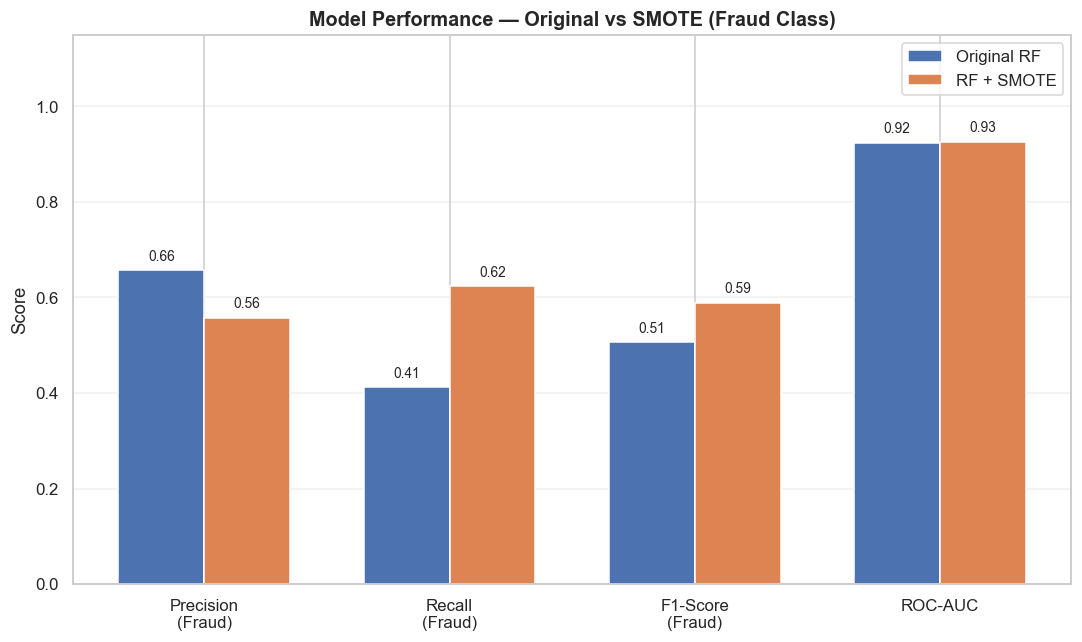

In [39]:

metric_names = ['Precision\n(Fraud)', 'Recall\n(Fraud)', 'F1-Score\n(Fraud)', 'ROC-AUC']
original_vals = [
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred),
    rf_auc
]
smote_vals = [
    precision_score(y_test, rf_smote_pred),
    recall_score(y_test, rf_smote_pred),
    f1_score(y_test, rf_smote_pred),
    rf_smote_auc
]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, original_vals, width, label='Original RF',
               color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, smote_vals, width, label='RF + SMOTE',
               color='#DD8452', edgecolor='white')

ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance — Original vs SMOTE (Fraud Class)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('smote_metric_comparison.png', bbox_inches='tight')
plt.show()
